# Предсказательная модель
## На основе биржевых данных (дата, открытие, закрытие, самая большая цена, самая низкая цена) можно предсказывать значение следующего закрытия сделки (по дням).


## Импорт необходимых библиотек

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import math

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

## Объединение данных
### Данные представляют собой многомерный массив файлов, состоящий из папок с временными фреймами, которые в свою очередь включают в себя тикеты компаний.

In [ ]:
data_dir = '/content/drive/MyDrive/archive'

def load_data(timeframe=None, tickers=None):
    """
    Загружает данные для указанного временного фрейма и тикеров с сортировкой по дате.
    :param timeframe: str, временной фрейм (например, 'day', '1h', '4h') или None для всех.
    :param tickers: list, список тикеров (например, ['SBER', 'GAZP']) или None для всех.
    :return: объединённый DataFrame, отсортированный по дате
    """
    all_data = []

    # Фильтрация по временным фреймам
    timeframes = [timeframe] if timeframe else os.listdir(data_dir)

    for tf in timeframes:
        tf_path = os.path.join(data_dir, tf)
        if not os.path.isdir(tf_path):
            continue

        # Фильтрация по тикерам
        files = os.listdir(tf_path)
        if tickers:
            files = [f"{ticker}.csv" for ticker in tickers if f"{ticker}.csv" in files]

        # Чтение данных
        for file in files:
            file_path = os.path.join(tf_path, file)
            df = pd.read_csv(file_path)

            # Добавляем тикер и временной фрейм
            df['ticker'] = file.replace('.csv', '')
            df['timeframe'] = tf

            # Приведение столбца с датой к datetime
            if 'date' in df.columns:
                df['date'] = pd.to_datetime(df['date'])
            elif 'datetime' in df.columns:
                df['datetime'] = pd.to_datetime(df['datetime'])

            all_data.append(df)

    # Объединяем данные и сортируем по дате
    if all_data:
        combined_df = pd.concat(all_data, ignore_index=True)
        # Сортировка по дате (или datetime, если есть)
        date_column = 'date' if 'date' in combined_df.columns else 'datetime'
        combined_df = combined_df.sort_values(by=[date_column, 'ticker']).reset_index(drop=True)
        return combined_df
    else:
        print("Нет данных для загрузки.")
        return pd.DataFrame()


In [ ]:
blue_chips = load_data(timeframe='D1', tickers=['CHMF_D1', 'SBER_D1', 'GAZP_D1', 'GMKN_D1',
                                        'LKOH_D1', 'MAGN_D1', 'NLMK_D1', 'NVTK_D1',
                                        'PLZL_D1', 'ROSN_D1', 'SNGS_D1', 'TCSG_D1',
                                        'TATN_D1', 'YNDX_D1'])
blue_chips['datetime'] = pd.to_datetime(blue_chips['datetime'])
blue_chips = blue_chips.sort_values(by='datetime')
blue_chips

,datetime,open,high,low,close,volume,ticker,timeframe
0,1999-06-01,228.50,228.50,223.10,225.00,12471,LKOH_D1,D1
1,1999-06-01,0.54,0.54,0.53,0.53,778,SBER_D1,D1
2,1999-06-01,3.85,3.87,3.75,3.75,12836,SNGS_D1,D1
3,1999-06-02,224.00,224.00,214.00,217.00,45341,LKOH_D1,D1
4,1999-06-02,0.53,0.53,0.49,0.50,1926,SBER_D1,D1
...,...,...,...,...,...,...,...,...
66162,2024-08-27,127.30,127.98,122.52,124.47,9250264,GAZP_D1,D1
66161,2024-08-27,1322.00,1349.20,1265.40,1275.20,1027922,CHMF_D1,D1
66172,2024-08-27,608.40,616.00,606.30,611.60,2371388,TATN_D1,D1
66166,2024-08-27,147.90,149.00,142.52,142.80,816174,NLMK_D1,D1


In [ ]:
# Добавляем столбцы с ростом
blue_chips['daily_growth'] = blue_chips.groupby('ticker')['close'].pct_change() * 100
blue_chips['weekly_growth'] = blue_chips.groupby('ticker')['close'].pct_change(periods=7) * 100
blue_chips['monthly_growth'] = blue_chips.groupby('ticker')['close'].pct_change(periods=30) * 100

# Вычисляем стабильность и волатильность с transform
blue_chips['daily_growth_std'] = blue_chips.groupby('ticker')['daily_growth'].transform('std')
blue_chips['daily_growth_mean'] = blue_chips.groupby('ticker')['daily_growth'].transform('mean')

# Стабильность: отношение std к среднему
blue_chips['stability'] = blue_chips['daily_growth_std'] / blue_chips['daily_growth_mean']

# Волатильность: просто std отклонение роста
blue_chips['volatility'] = blue_chips['daily_growth_std']

blue_chips['sharpe_ratio'] = blue_chips['daily_growth_mean'] / blue_chips['daily_growth_std']

blue_chips['high_low'] = blue_chips['high'] - blue_chips['low']
blue_chips['high_close_prev'] = abs(blue_chips['high'] - blue_chips['close'].shift(1))
blue_chips['low_close_prev'] = abs(blue_chips['low'] - blue_chips['close'].shift(1))

blue_chips['true_range'] = blue_chips[['high_low', 'high_close_prev', 'low_close_prev']].max(axis=1)
blue_chips['atr_14'] = blue_chips.groupby('ticker')['true_range'].transform(lambda x: x.rolling(window=14).mean())

blue_chips

,datetime,open,high,low,close,volume,ticker,timeframe,daily_growth,weekly_growth,...,daily_growth_std,daily_growth_mean,stability,volatility,sharpe_ratio,high_low,high_close_prev,low_close_prev,true_range,atr_14
0,1999-06-01,228.50,228.50,223.10,225.00,12471,LKOH_D1,D1,NaN,NaN,...,2.352561,0.081129,28.997855,2.352561,0.034485,5.40,NaN,NaN,5.40,NaN
1,1999-06-01,0.54,0.54,0.53,0.53,778,SBER_D1,D1,NaN,NaN,...,2.842464,0.138926,20.460256,2.842464,0.048875,0.01,224.46,224.47,224.47,NaN
2,1999-06-01,3.85,3.87,3.75,3.75,12836,SNGS_D1,D1,NaN,NaN,...,2.712553,0.065879,41.175049,2.712553,0.024287,0.12,3.34,3.22,3.34,NaN
3,1999-06-02,224.00,224.00,214.00,217.00,45341,LKOH_D1,D1,-3.555556,NaN,...,2.352561,0.081129,28.997855,2.352561,0.034485,10.00,220.25,210.25,220.25,NaN
4,1999-06-02,0.53,0.53,0.49,0.50,1926,SBER_D1,D1,-5.660377,NaN,...,2.842464,0.138926,20.460256,2.842464,0.048875,0.04,216.47,216.51,216.51,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
66162,2024-08-27,127.30,127.98,122.52,124.47,9250264,GAZP_D1,D1,-1.837539,-1.495726,...,2.360528,0.015979,147.725653,2.360528,0.006769,5.46,15.08,9.62,15.08,5.918571
66161,2024-08-27,1322.00,1349.20,1265.40,1275.20,1027922,CHMF_D1,D1,-3.291370,-7.258182,...,2.546274,0.069311,36.737114,2.546274,0.027220,83.80,1224.73,1140.93,1224.73,1244.622143
66172,2024-08-27,608.40,616.00,606.30,611.60,2371388,TATN_D1,D1,0.625206,1.797603,...,2.671847,0.101197,26.402352,2.671847,0.037875,9.70,659.20,668.90,668.90,1144.232143
66166,2024-08-27,147.90,149.00,142.52,142.80,816174,NLMK_D1,D1,-3.028657,-11.884487,...,2.775251,0.056313,49.282820,2.775251,0.020291,6.48,462.60,469.08,469.08,1782.592857


## Реализация ARMAExo(g)

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.tsa.seasonal import seasonal_decompose

class ARMAExo:
    def __init__(self, p=1, window=10, confidence=0.95):
        self.p = p
        self.window = window
        self.confidence = confidence
        self.ar_coef = None
        self.exog_coef = None
        self.ema_values = None
        self.residuals = None

    def difference(self, y, order=1):
        return np.diff(y, n=order)

    def ar_model(self, y):
        X = np.array([y[i:len(y) - self.p + i] for i in range(self.p)]).T
        y_target = y[self.p:]
        self.ar_coef = np.linalg.lstsq(X, y_target, rcond=None)[0]
        y_pred = X @ self.ar_coef
        self.residuals = y_target - y_pred
        return self.ar_coef

    def ma(self, errors):
        """Вычисление простого скользящего среднего (MA)"""
        ma_values = []
        for i in range(len(errors)):
            # Получаем окно предыдущих значений ошибок
            window_errors = errors[max(0, i - self.window + 1):i + 1]
            ma_values.append(np.mean(window_errors))
        self.ma_values = np.array(ma_values)
        return self.ma_values

    def exog_model(self, y, X_exog):
        ar_coef = self.ar_model(y)
        X_ar = np.array([y[i:len(y) - self.p + i] for i in range(self.p)]).T
        errors = y[self.p:] - np.dot(X_ar, ar_coef)
        ma_values = self.ma(errors)
        X_exog_lagged = X_exog[self.p:, :]
        if X_exog_lagged.shape[0] != len(ma_values):
            raise ValueError("Размерности X_exog и EMA значений не совпадают!")
        self.exog_coef = np.linalg.lstsq(X_exog_lagged, ma_values, rcond=None)[0]
        return ar_coef, self.ma_values, self.exog_coef

    def forecast(self, y, X_exog, steps=1):
        y_pred = list(y[-self.p:])
        X_exog_pred = X_exog[-self.p:, :]
        forecasts = []
        lower_bounds = []
        upper_bounds = []
        std_error = np.std(self.residuals) if self.residuals is not None else 1.0
        z_score = norm.ppf(1 - (1 - self.confidence) / 2)
        for step in range(steps):
            ar_part = np.dot(self.ar_coef, y_pred[-self.p:])
            exog_part = np.dot(X_exog_pred[-1], self.exog_coef)
            next_value = ar_part + exog_part
            forecasts.append(next_value)
            y_pred.append(next_value)
            lower_bounds.append(next_value - z_score * std_error * math.log(step+1 * 10, 10))
            upper_bounds.append(next_value + z_score * std_error * math.log(step+1 * 10, 10))
            X_exog_pred = np.vstack([X_exog_pred, X_exog[-1]])
        return np.array(forecasts), np.array(lower_bounds), np.array(upper_bounds)


## Тест предсказательной модели ARMAExo(g)

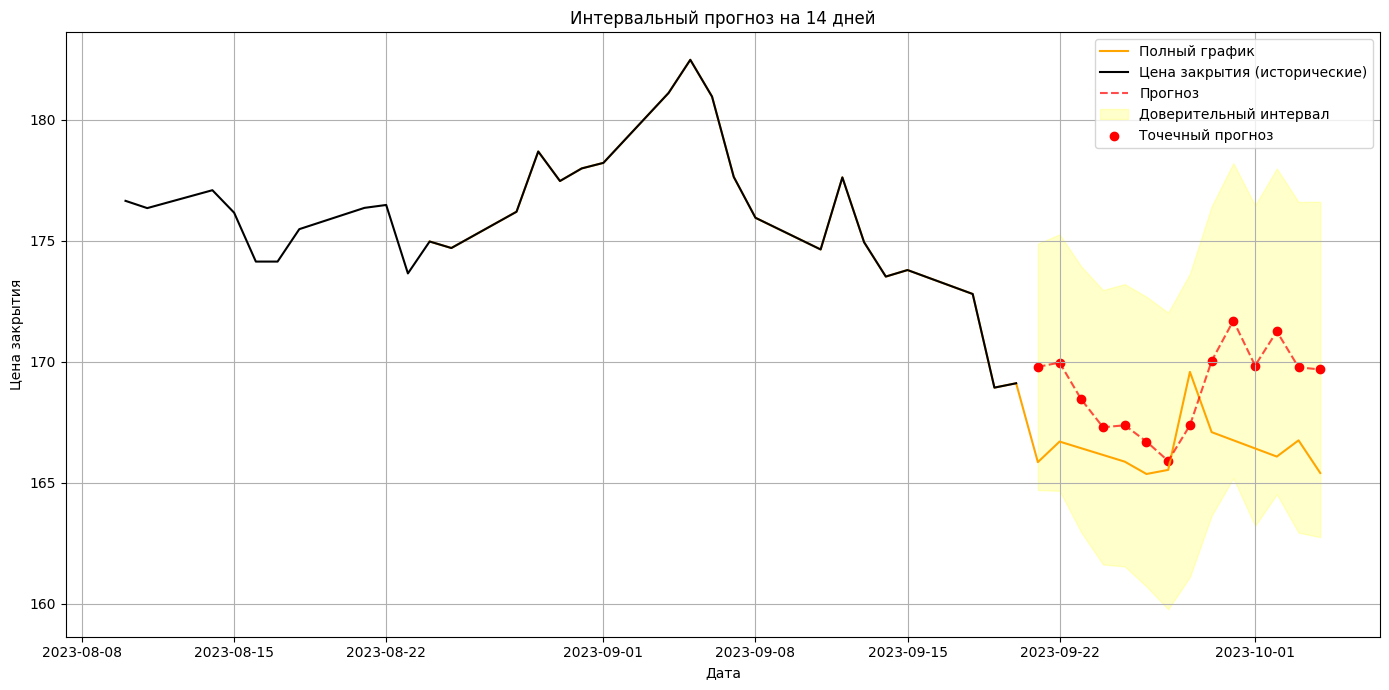


Прогноз на 14 дней:
         Дата     Прогноз  Нижняя граница  Верхняя граница
0  2023-09-21  169.787958      164.697441       174.878475
1  2023-09-22  169.965256      164.664028       175.266483
2  2023-09-23  168.439867      162.946276       173.933458
3  2023-09-24  167.290861      161.620313       172.961409
4  2023-09-25  167.374096      161.539711       173.208480
5  2023-09-26  166.699499      160.712586       172.686412
6  2023-09-27  165.898772      159.769179       172.028366
7  2023-09-28  167.372219      161.108597       173.635840
8  2023-09-29  170.032044      163.642058       176.422030
9  2023-09-30  171.698630      165.189113       178.208147
10 2023-10-01  169.839757      163.216841       176.462672
11 2023-10-02  171.254359      164.523579       177.985139
12 2023-10-03  169.769252      162.935626       176.602878
13 2023-10-04  169.679907      162.748008       176.611806


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Подготовка исходных данных
ticker_data = (blue_chips.groupby('ticker')
                          .get_group('GAZP_D1')
                          .sort_values(by='datetime')
                          .reset_index(drop=True))

# Запрос диапазона дат у пользователя
end_date = '2023-09-20'

# Фильтрация данных по выбранному диапазону
filtered_data = ticker_data[ticker_data['datetime'] <= pd.to_datetime(end_date)].reset_index(drop=True)
# Подготовка данных для модели
y = filtered_data['close'].values
X_exo = filtered_data[['volume', 'stability', 'volatility', 'open', 'high', 'low',
                       'daily_growth', 'weekly_growth', 'monthly_growth',
                       'sharpe_ratio', 'high_low', 'high_close_prev', 'low_close_prev', 'true_range', 'atr_14']].values
dates = pd.to_datetime(filtered_data['datetime'])

# Проверка наличия данных
if len(y) < 2:
    print("Недостаточно данных для прогноза. Убедитесь, что диапазон дат корректен.")
else:
    # Создание и настройка модели
    model = ARMAExo(p=300, window=180, confidence=0.75)  # Параметр p можно настроить под задачу

    # Обучение модели
    model.exog_model(y, X_exo)

    # Прогноз
    steps = 14
    forecast, lower, upper = model.forecast(y, X_exo, steps=steps)

    # Генерация дат для прогноза
    data = ticker_data[ticker_data['datetime'] <= pd.to_datetime(end_date)+pd.Timedelta(days=steps)]
    # Выполнение прогноза и визуализация
    forecast_dates = pd.date_range(start=dates.iloc[-1] + pd.Timedelta(days=1), periods=steps, freq='D')

    # Данные прогноза
    forecast_data = pd.DataFrame({
        'Дата': forecast_dates,
        'Прогноз': forecast,
        'Нижняя граница': lower,
        'Верхняя граница': upper
    })

    # Исторические данные
    historical_data = pd.DataFrame({
        'Дата': dates,
        'Цена': y
    })

    # Создание дополнительной линии с датами от начала исторических до конца прогноза
    combined_dates = pd.concat([pd.Series(dates), pd.Series(forecast_dates)], ignore_index=True)
    combined_prices = np.concatenate([y, forecast])  # Объединяем реальные данные и прогноз

    # Визуализация
    plt.figure(figsize=(14, 7))

    # Исторические данные (последние 30 точек)
    plt.plot(data['datetime'][-30:], data['close'][-30:], label='Полный график', color='orange', linestyle='-')
    plt.plot(historical_data['Дата'][-30:], historical_data['Цена'][-30:], label='Цена закрытия (исторические)', color='black', alpha=1)

    # Прогноз
    plt.plot(forecast_data['Дата'], forecast_data['Прогноз'], label='Прогноз', color='red', alpha=0.7, linestyle='--')

    # Доверительный интервал
    plt.fill_between(forecast_data['Дата'], forecast_data['Нижняя граница'],
                     forecast_data['Верхняя граница'], color='yellow', alpha=0.2, label='Доверительный интервал')

    # Точечные значения прогноза и границ
    plt.scatter(forecast_data['Дата'], forecast_data['Прогноз'], color='red', label='Точечный прогноз')
    # Дополнительная линия (все данные вместе)

    # Оформление
    plt.title('Интервальный прогноз на {} дней'.format(steps))
    plt.xlabel('Дата')
    plt.ylabel('Цена закрытия')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Вывод прогноза
    print("\nПрогноз на {} дней:".format(steps))
    print(forecast_data)


## Подсчет метрик ARMAExo(g)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
ticker_data = (blue_chips.groupby('ticker')
                          .get_group('GAZP_D1')
                          .sort_values(by='datetime')
                          .reset_index(drop=True))
# Запрос диапазона дат у пользователя
end_date = '2023-09-20'

# Фильтрация данных по выбранному диапазону
filtered_data = ticker_data[ticker_data['datetime'] <= pd.to_datetime(end_date)].reset_index(drop=True)

# Подготовка данных для модели
y = filtered_data['close'].values
X_exo = filtered_data[['volume', 'stability', 'volatility', 'open', 'high', 'low',
                       'daily_growth', 'weekly_growth', 'monthly_growth',
                       'sharpe_ratio', 'high_low', 'high_close_prev', 'low_close_prev', 'true_range', 'atr_14']].values

# Проверка наличия данных
if len(y) < 2:
    print("Недостаточно данных для прогноза. Убедитесь, что диапазон дат корректен.")
else:
    # Создание и настройка модели
    model = ARMAExo(p=365, window=180, confidence=0.75)  # Параметры p и window можно настроить под задачу

    # Обучение модели
    model.exog_model(y, X_exo)

    # Прогноз на 20 шагов вперед
    steps = 5
    forecast, lower, upper = model.forecast(y, X_exo, steps=steps)

    # Пример реальных значений (для оценки прогноза)
    true_values = y[-steps:]  # Пример реальных значений для последующих дней

    # Вычисление метрик
    mae = mean_absolute_error(true_values, forecast)
    mse = mean_squared_error(true_values, forecast)
    rmse = np.sqrt(mse)
    r2 = r2_score(true_values, forecast)

    # Вывод результатов
    print(f"MAE: {mae}")
    print(f"MSE: {mse}")
    print(f"RMSE: {rmse}")
    print(f"R²: {r2}")

MAE: 2.9406948680391
MSE: 9.99810306190201
RMSE: 3.1619777136947076
R²: -1.1504071626235732


## Вывод:

*   Модель способна как на краткосрочные предсказания (1-5) дней, так и на долгосрочные (100-200 дней)
*   Модель не учитывает новостной подтекст, не различает локальные тренды, не учитывает сезонность
*   На основе исторических данных может предсказывать “разворот” цены акции
Модель способна работать со статическими и нестатическими рядами.
*   Модель конкурентноспособна на долгосрочных предсказаниях


# Классификация

## Формирование DF НЕ голубых фишек

In [ ]:
tickers = ['CHMF_D1', 'SBER_D1', 'GAZP_D1', 'GMKN_D1', 'LKOH_D1', 'MAGN_D1', 'NLMK_D1',
           'NVTK_D1', 'PLZL_D1', 'ROSN_D1', 'SNGS_D1', 'TCSG_D1', 'TATN_D1', 'YDEX_D1']
actual_path = os.path.join(data_dir, "D1")
other_data = list()
for filename in os.listdir(actual_path):
    file_path = os.path.join(actual_path, filename)
    if not(filename.split('.')[0] in tickers):
        other_data.append(filename.split('.')[0])
print(len(other_data))

236


In [ ]:
other_chips = load_data(timeframe='D1', tickers=other_data)
other_chips['datetime'] = pd.to_datetime(other_chips['datetime'])
other_chips = other_chips.sort_values(by='datetime')
other_chips

,datetime,open,high,low,close,volume,ticker,timeframe
0,1999-06-01,0.67500,0.6900,0.65900,0.6600,2007,MSNG_D1,D1
1,1999-06-01,28.22000,28.2200,28.00000,28.0000,2,RTKM_D1,D1
2,1999-06-01,0.29000,0.2900,0.28000,0.2800,40200,SBERP_D1,D1
3,1999-06-01,1.11000,1.1100,1.08500,1.0850,8639,SNGSP_D1,D1
4,1999-06-02,6.30000,6.3000,6.30000,6.3000,10,MFGS_D1,D1
...,...,...,...,...,...,...,...,...
702731,2024-08-27,14.24000,14.9000,14.20000,14.5000,969,KRSBP_D1,D1
702732,2024-08-27,14.20000,14.9600,14.00000,14.6600,628,KRSB_D1,D1
702733,2024-08-27,0.75500,0.7670,0.72100,0.7600,24,KTSBP_D1,D1
702763,2024-08-27,0.05985,0.0601,0.05915,0.0592,7559,MRKV_D1,D1


## Подсчет признаков

In [ ]:
def calculate_features(df):
    """
    Рассчитывает признаки для тикеров:
    - Средний объем торгов (avg_volume)
    - Волатильность (volatility)
    - Темпы роста цен (growth_rate)
    """
    features = []

    for ticker in df['ticker'].unique():
        data = df[df['ticker'] == ticker]

        avg_volume = data['volume'].mean()
        volatility = data['close'].pct_change().std()  # Волатильность по процентным изменениям
        growth_rate = (data['close'].iloc[-1] / data['close'].iloc[0]) - 1  # Темп роста за весь период

        features.append({
            'ticker': ticker,
            'avg_volume': avg_volume,
            'volatility': volatility,
            'growth_rate': growth_rate
        })

    return pd.DataFrame(features)

## Разметка данных

In [ ]:
blue_chip_features = calculate_features(blue_chips)
blue_chip_features['target'] = 1  # Метка для синих фишек

# Расчет признаков для других тикеров
other_chip_features = calculate_features(other_chips)
other_chip_features['target'] = 0  # Метка для остальных

# Выбираем только числовые столбцы
numeric_columns = other_chip_features.select_dtypes(include=[np.number]).columns
other_chip_features_numeric = other_chip_features[numeric_columns]

# Обработка бесконечностей и NaN
other_chip_features_numeric = other_chip_features_numeric.replace([np.inf, -np.inf], np.nan)  # Заменяем inf на NaN
other_chip_features_numeric = other_chip_features_numeric.fillna(other_chip_features_numeric.mean())  # Заменяем NaN средними значениями по столбцу

# Обновляем исходный DataFrame с обработанными данными
other_chip_features[numeric_columns] = other_chip_features_numeric

<ipython-input-15-da87b9ca1814>:15: RuntimeWarning: divide by zero encountered in scalar divide
  growth_rate = (data['close'].iloc[-1] / data['close'].iloc[0]) - 1  # Темп роста за весь период


In [ ]:
# Объединяем признаки для обучения
all_features = pd.concat([blue_chip_features, other_chip_features], ignore_index=True)
X = all_features[['avg_volume', 'volatility', 'growth_rate']]
y = all_features['target']

# Разделяем данные на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Обучаем модель
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Оцениваем модель
y_pred = model.predict(X_test)
print("Classification Report:\n", classification_report(y_test, y_pred))

# Предсказание кандидатов среди других тикеров
other_chip_features['prediction'] = model.predict(other_chip_features[['avg_volume', 'volatility', 'growth_rate']])
blue_chip_features['prediction'] = model.predict(blue_chip_features[['avg_volume', 'volatility', 'growth_rate']])
candidates = other_chip_features[other_chip_features['prediction'] == 1]
candidates_2 = blue_chip_features[blue_chip_features['prediction'] == 1]

# Выводим кандидатов
print("Кандидаты в синие фишки:")
print(candidates[['ticker', 'avg_volume', 'volatility', 'growth_rate']])
print(candidates_2[['ticker', 'avg_volume', 'volatility', 'growth_rate']])

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.98      0.96        47
           1       0.00      0.00      0.00         3

    accuracy                           0.92        50
   macro avg       0.47      0.49      0.48        50
weighted avg       0.88      0.92      0.90        50

Кандидаты в синие фишки:
       ticker    avg_volume  volatility  growth_rate
2    SBERP_D1  1.473965e+06    0.029771   928.214286
190   YNDX_D1  5.339196e+05    0.024888     2.479658
     ticker    avg_volume  volatility  growth_rate
0   LKOH_D1  1.414817e+06    0.023526    28.006667
1   SBER_D1  8.098579e+06    0.028425   490.509434
2   SNGS_D1  3.384118e+05    0.027126     5.466667
3   GMKN_D1  3.211617e+08    0.024584    28.710526
4   TATN_D1  2.207641e+06    0.026718    40.605442
5   CHMF_D1  1.119949e+06    0.025463     4.822831
7   GAZP_D1  4.709534e+06    0.023605    -0.431358
8   NLMK_D1  4.234980e+05    0.027753     1.259494
11  NV

## Результаты классификации

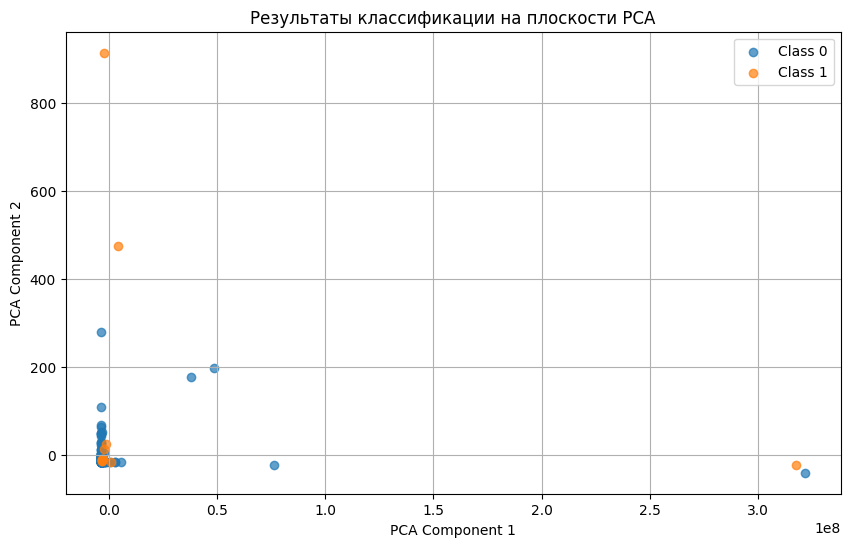

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Применим PCA для понижения размерности до 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Получим предсказанные метки классов
y_pred = model.predict(X)

# Создаём DataFrame для удобства
result_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
result_df['Class'] = y_pred

# Визуализация результатов классификации
plt.figure(figsize=(10, 6))
for label in np.unique(y_pred):
    plt.scatter(
        result_df[result_df['Class'] == label]['PCA1'],
        result_df[result_df['Class'] == label]['PCA2'],
        label=f'Class {label}',
        alpha=0.7
    )

plt.title("Результаты классификации на плоскости PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()

## Результаты классификации Спирмана

<ipython-input-22-8080d1dde215>:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations = merged_data.groupby('ticker').apply(calculate_spearman_correlation)


Отсортированная корреляция Спирмена с MOEX по синим фишкам:
ticker
SBER_D1    0.846327
CHMF_D1    0.828231
MAGN_D1    0.820293
NLMK_D1    0.801160
ROSN_D1    0.795972
PLZL_D1    0.792550
LKOH_D1    0.767698
NVTK_D1    0.730288
YNDX_D1    0.709192
GMKN_D1    0.653873
TATN_D1    0.589888
TCSG_D1    0.566240
SNGS_D1    0.434412
GAZP_D1    0.363788
dtype: float64


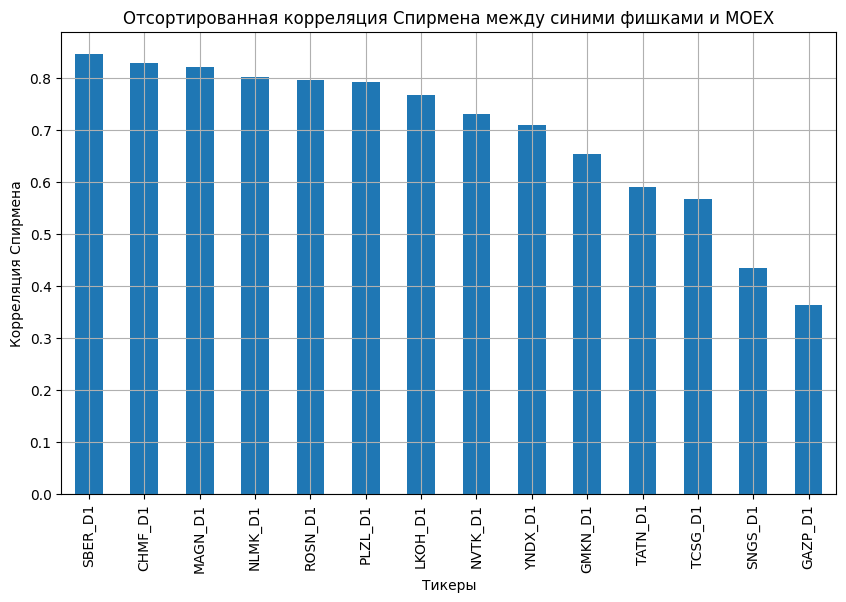

In [ ]:
from scipy.stats import spearmanr

# Загрузим данные MOEX
moex = load_data(timeframe='D1', tickers=["MOEX_D1"])
moex['datetime'] = pd.to_datetime(moex['datetime'])
moex = moex.sort_values(by='datetime')

# Объединим данные "синих фишек" и MOEX по дате
merged_data = blue_chips.merge(
    moex[['datetime', 'close']],
    on='datetime',
    how='inner',
    suffixes=('', '_moex')
)

# Функция для вычисления корреляции Спирмена
def calculate_spearman_correlation(group):
    return spearmanr(group['close'], group['close_moex']).correlation  # Возвращаем только коэффициент корреляции

# Посчитаем корреляцию Спирмена для каждого тикера
correlations = merged_data.groupby('ticker').apply(calculate_spearman_correlation)

# Сортировка корреляций по убыванию
sorted_correlations = correlations.sort_values(ascending=False)

# Выведем отсортированные результаты
print("Отсортированная корреляция Спирмена с MOEX по синим фишкам:")
print(sorted_correlations)

# Визуализация отсортированной корреляции
sorted_correlations.plot(kind='bar', figsize=(10, 6), title="Отсортированная корреляция Спирмена между синими фишками и MOEX")
plt.ylabel("Корреляция Спирмена")
plt.xlabel("Тикеры")
plt.grid(True)
plt.show()